In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
competitor_df = pd.read_csv("../data/competitorpricingdata.csv")
customer_behavior_df = pd.read_csv("../data/dailycustomerbehavior.csv")
sales_df = pd.read_csv("../data/tidesalesdata.csv")
inventory_df = pd.read_csv("../data/tidewarehouseinventorysim.csv")

In [3]:
len(competitor_df), len(customer_behavior_df), len(sales_df), len(inventory_df)

(2190, 365, 1095, 21900)

### Competitor Data

In [4]:
competitor_df.columns

Index(['Date', 'Brand', 'MRP', 'DiscountRate', 'BasePrice', 'FinalPrice'], dtype='object')

#### We got 2 competitor brands -- Nirma and Surf Excel

In [5]:
competitor_df["Brand"].unique()

array(['Nirma', 'Surf Excel'], dtype=object)

#### We got equal number of records for both the competitors

In [6]:
competitor_df[competitor_df["Brand"]=="Nirma"]

,Date,Brand,MRP,DiscountRate,BasePrice,FinalPrice
0,01-01-2021,Nirma,90.00,0.00,84.67,84.67
2,02-01-2021,Nirma,90.00,0.00,81.16,81.16
4,03-01-2021,Nirma,90.00,0.00,79.33,79.33
6,04-01-2021,Nirma,90.00,0.00,76.72,76.72
8,05-01-2021,Nirma,90.00,0.24,70.80,60.00
...,...,...,...,...,...,...
2180,27-12-2023,Nirma,97.34,0.00,73.24,73.24
2182,28-12-2023,Nirma,97.34,0.00,77.00,77.00
2184,29-12-2023,Nirma,97.34,0.00,78.21,78.21
2186,30-12-2023,Nirma,97.34,0.00,91.75,91.75


In [7]:
competitor_df.describe()

,MRP,DiscountRate,BasePrice,FinalPrice
count,2190.000000,2190.000000,2190.000000,2190.000000
mean,104.620000,0.016726,93.550507,92.155105
std,11.643518,0.048882,14.308207,15.420338
min,90.000000,0.000000,61.720000,60.000000
25%,93.600000,0.000000,79.990000,78.780000
50%,103.670000,0.000000,93.130000,90.025000
75%,115.500000,0.000000,107.240000,107.007500
max,121.280000,0.250000,119.140000,119.140000


#### We don't have any null values in competitors data

In [8]:
competitor_df.isnull().sum()

Date            0
Brand           0
MRP             0
DiscountRate    0
BasePrice       0
FinalPrice      0
dtype: int64

In [9]:
competitor_df['Date'] = pd.to_datetime(competitor_df['Date'], format='%d-%m-%Y')

#### MRP over time for each brand

1. We can see that, both our competitors update their MRPs annually and then the price remain constant for the whole year.
2. Surf excel places their brand on higher side of price comparatively
3. Both the brands, increase their MRPs by same amount each year i.e: 5% for surf excel and 4% for nirma

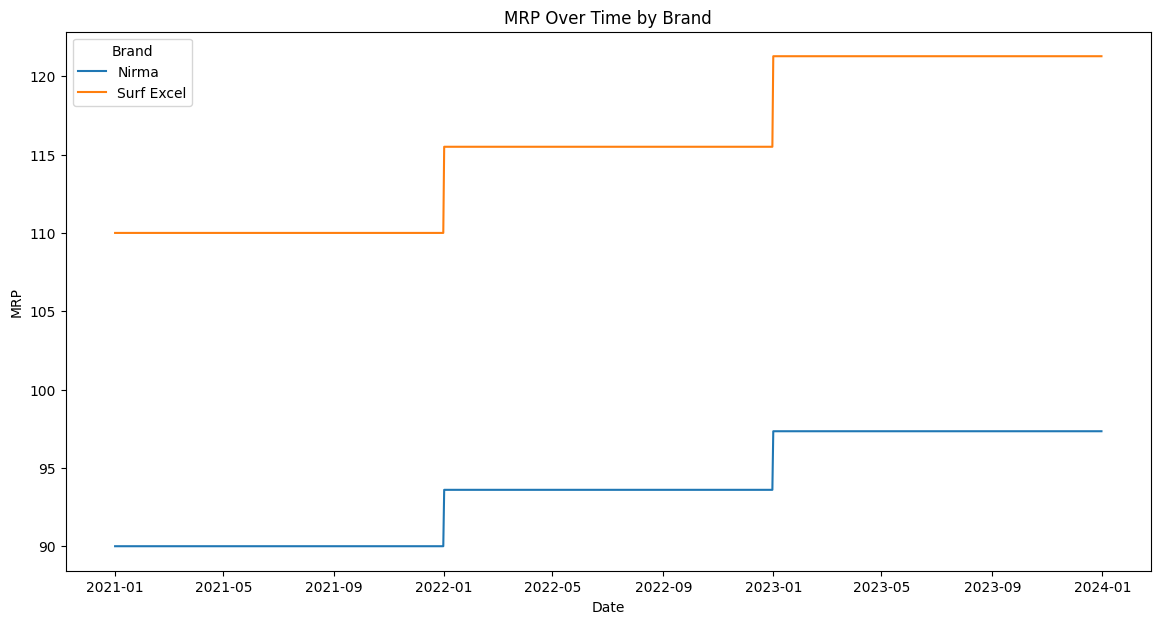

In [10]:
# Plotting the data
plt.figure(figsize=(14, 7))

# Plot MRP over time for each brand
sns.lineplot(data=competitor_df, x='Date', y='MRP', hue='Brand')
plt.title('MRP Over Time by Brand')
plt.xlabel('Date')
plt.ylabel('MRP')
plt.legend(title='Brand')
plt.show()

#### DiscountRate vs Brands
1. Nirma provides higher discounts compared to Surf Excel (Ref. fig. 2)
2. Nirma provides highest discount of 25% vs. Surf excel provides highest discount of 15%
3. There are a total of 1921 records with 0% discount (~88%)

In [11]:
# Calculate the minimum and maximum discount rate for each brand
discount_stats = competitor_df.groupby('Brand')['DiscountRate'].agg(['min', 'max']).reset_index()
discount_stats.columns = ['Brand', 'MinDiscountRate', 'MaxDiscountRate']
print(discount_stats)

        Brand  MinDiscountRate  MaxDiscountRate
0       Nirma              0.0             0.25
1  Surf Excel              0.0             0.15


##### Fig 1

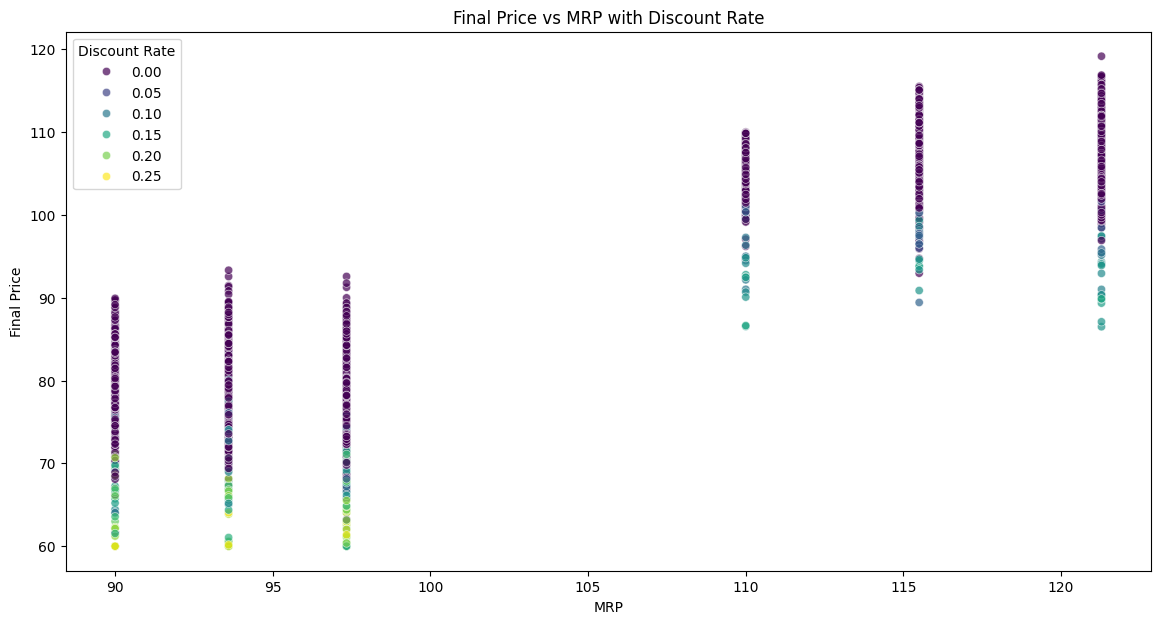

In [12]:
# Plotting the data
plt.figure(figsize=(14, 7))

# Plot Final Price vs MRP with DiscountRate as color
sns.scatterplot(data=competitor_df, x='MRP', y='FinalPrice', hue='DiscountRate', palette='viridis', alpha=0.7)
plt.title('Final Price vs MRP with Discount Rate')
plt.xlabel('MRP')
plt.ylabel('Final Price')
plt.legend(title='Discount Rate')
plt.show()

##### Fig 2

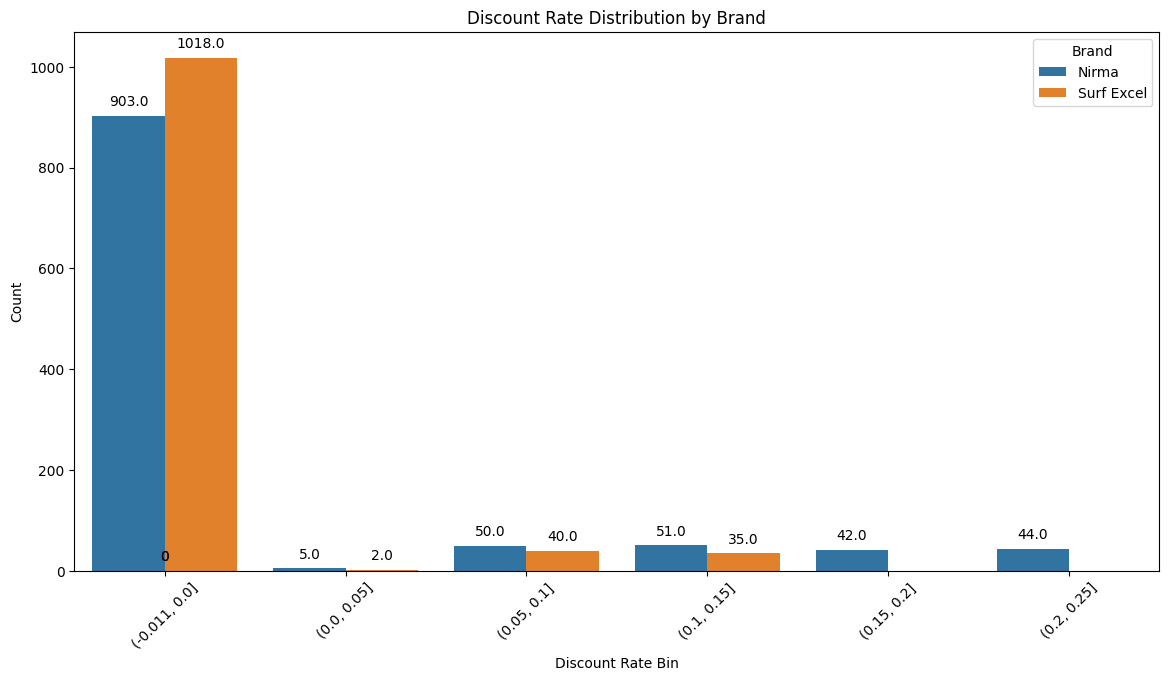

In [ ]:
competitor_df['DiscountRateBin'] = pd.cut(competitor_df['DiscountRate'], bins=[-0.01, 0, 0.05, 0.1, 0.15, 0.2, 0.25], include_lowest=True)

# Plotting the data
plt.figure(figsize=(14, 7))

# Plot bar chart
ax = sns.countplot(data=competitor_df, x='DiscountRateBin', hue='Brand')
plt.title('Discount Rate Distribution by Brand')
plt.xlabel('Discount Rate Bin')
plt.ylabel('Count')
plt.legend(title='Brand')
plt.xticks(rotation=45)

# Add counts on top of bars
for p in ax.patches:
    ax.annotate(f'{p.get_height()}', (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='center', xytext=(0, 10), textcoords='offset points')

plt.show()

### Date vs DiscountRate -- Seasonality of DiscountRate [Sophisticated :P]

The probability of both the brands providing discounts at same time is less

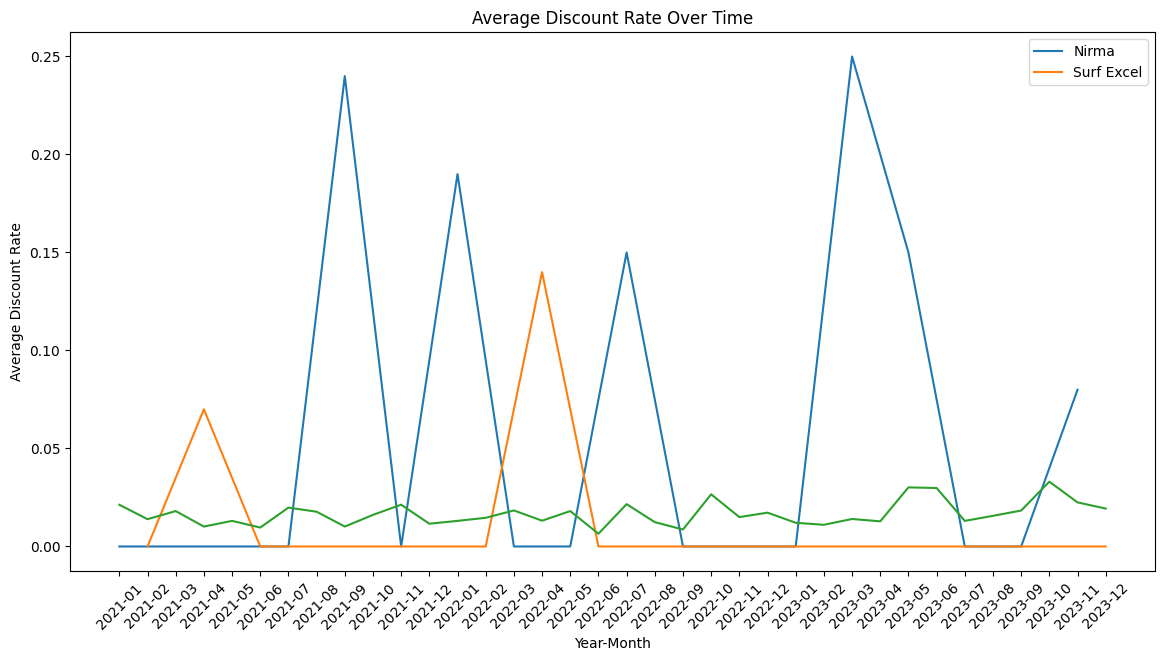

In [14]:
# Extract month and year from the 'Date' column
competitor_df['YearMonth'] = competitor_df['Date'].dt.to_period('M')

# Calculate the average discount rate for each month
monthly_avg_discount = competitor_df.groupby('YearMonth')['DiscountRate'].mean().reset_index()

# print(monthly_avg_discount.head())

# Plotting the data
plt.figure(figsize=(14, 7))
# Plot average discount rate over time for each brand -- Showcasing average discount price for each brand
sns.lineplot(data=competitor_df, x=monthly_avg_discount['YearMonth'].astype(str), y='DiscountRate', hue='Brand')
# Plot average discount rate over time -- Showcasing overall average discount price
sns.lineplot(data=monthly_avg_discount, x=monthly_avg_discount['YearMonth'].astype(str), y='DiscountRate')
plt.title('Average Discount Rate Over Time')
plt.xlabel('Year-Month')
plt.ylabel('Average Discount Rate')
plt.xticks(rotation=45)
plt.show()

<Figure size 1400x700 with 0 Axes>

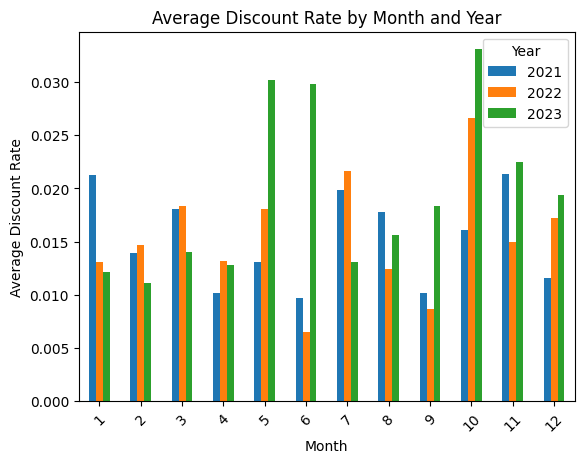

In [15]:
# Extract month and year from the 'Date' column
competitor_df['Month'] = competitor_df['Date'].dt.month
competitor_df['Year'] = competitor_df['Date'].dt.year

# Calculate the average discount rate for each month and brand
monthly_avg_discount_brand = competitor_df.groupby(['Year', 'Month', 'Brand'])['DiscountRate'].mean().reset_index()

# Pivot the data to have years as columns
monthly_avg_discount_pivot = monthly_avg_discount_brand.groupby(['Year', 'Month'])['DiscountRate'].mean().unstack().T.reset_index()

# Plotting the data
plt.figure(figsize=(14, 7))

# Plot bar chart
monthly_avg_discount_pivot.plot(kind='bar', x='Month', stacked=False)

plt.title('Average Discount Rate by Month and Year')
plt.xlabel('Month')
plt.ylabel('Average Discount Rate')
plt.legend(title='Year')
plt.xticks(rotation=45)
plt.show()

In [16]:
# Find the month with the maximum discount rate for each brand annually
max_discount_month_annual = competitor_df.loc[competitor_df.groupby(['Brand', competitor_df['Date'].dt.year])['DiscountRate'].idxmax(), ['Brand', 'YearMonth', 'DiscountRate']]
max_discount_month_annual['Year'] = max_discount_month_annual['YearMonth'].dt.year

# Print the month with the maximum discount rate for each brand annually
for year in max_discount_month_annual['Year'].unique():
    print(f"Year: {year}")
    print(max_discount_month_annual[max_discount_month_annual['Year'] == year])

Year: 2021
          Brand YearMonth  DiscountRate  Year
26        Nirma   2021-01          0.25  2021
587  Surf Excel   2021-10          0.15  2021
Year: 2022
           Brand YearMonth  DiscountRate  Year
1284       Nirma   2022-10          0.25  2022
931   Surf Excel   2022-04          0.15  2022
Year: 2023
           Brand YearMonth  DiscountRate  Year
1946       Nirma   2023-09          0.25  2023
1731  Surf Excel   2023-05          0.15  2023


### Baseprice vs Finalprice vs MRP -- Brand specifc
This jsutify that surf excel doesn't provide much discounts and is on the higher end of price, still less than MRP

C:\Users\10677003\AppData\Local\Temp\ipykernel_20192\2726253459.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  nirma_df['YearMonth'] = nirma_df['Date'].dt.to_period('M')


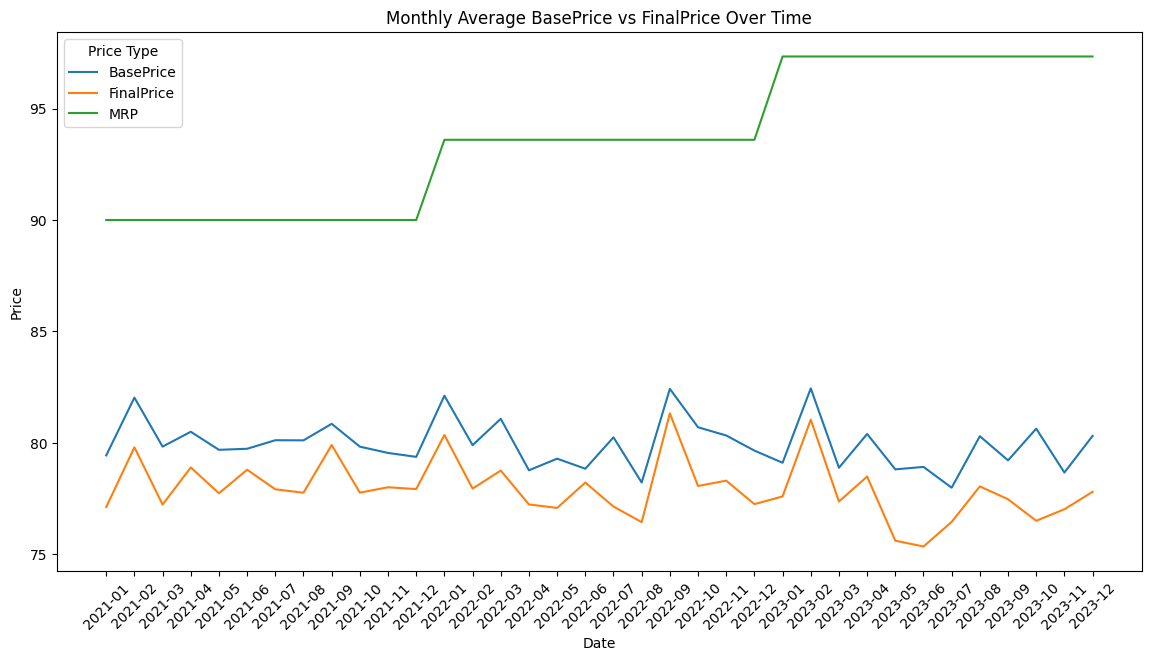

In [17]:
# Plotting the data
plt.figure(figsize=(14, 7))

nirma_df = competitor_df[competitor_df["Brand"]=="Nirma"]
surf_excel_df = competitor_df[competitor_df["Brand"]=="Surf Excel"]

# Take a monthly average of BasePrice and FinalPrice
nirma_df['YearMonth'] = nirma_df['Date'].dt.to_period('M')
monthly_avg_price_nirma = nirma_df.groupby('YearMonth')[['BasePrice', 'FinalPrice', 'MRP']].mean().reset_index()

# Plot monthly average prices
sns.lineplot(data=monthly_avg_price_nirma, x=monthly_avg_price_nirma['YearMonth'].astype(str), y='BasePrice', label='BasePrice')
sns.lineplot(data=monthly_avg_price_nirma, x=monthly_avg_price_nirma['YearMonth'].astype(str), y='FinalPrice', label='FinalPrice')
sns.lineplot(data=monthly_avg_price_nirma, x=monthly_avg_price_nirma['YearMonth'].astype(str), y='MRP', label='MRP')

plt.title('Monthly Average BasePrice vs FinalPrice Over Time')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend(title='Price Type')
plt.xticks(rotation=45)
plt.show()

C:\Users\10677003\AppData\Local\Temp\ipykernel_20192\3166633332.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  surf_excel_df['YearMonth'] = surf_excel_df['Date'].dt.to_period('M')


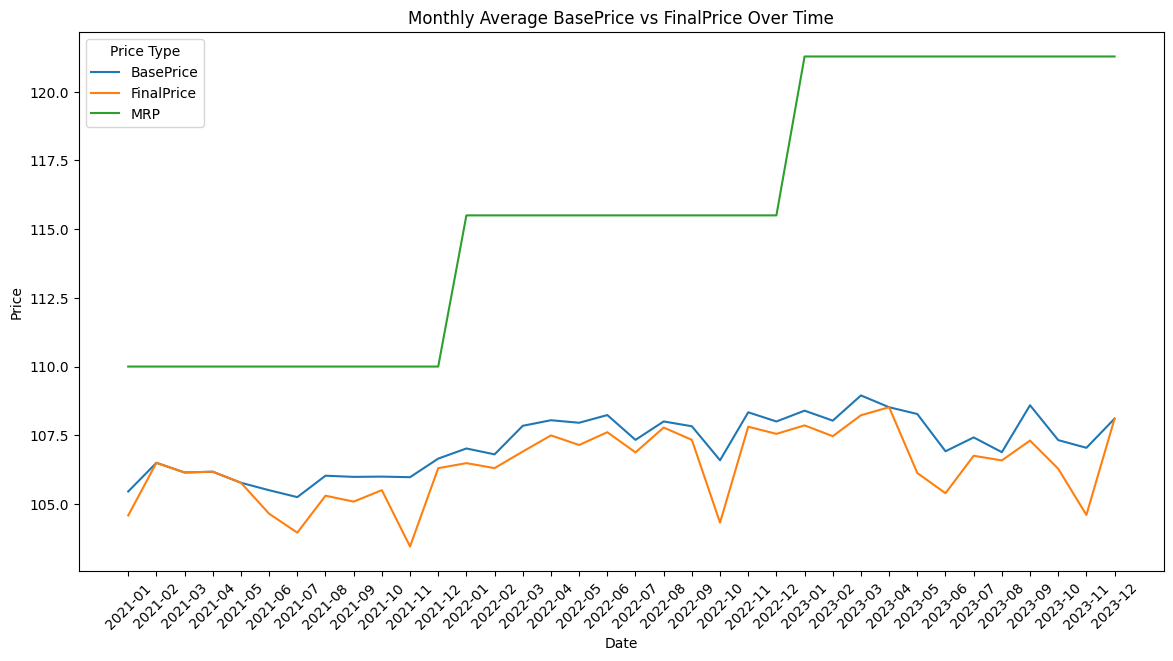

In [18]:
# Plotting the data
plt.figure(figsize=(14, 7))

surf_excel_df = competitor_df[competitor_df["Brand"]=="Surf Excel"]

# Take a monthly average of BasePrice and FinalPrice
surf_excel_df['YearMonth'] = surf_excel_df['Date'].dt.to_period('M')
monthly_avg_price_se = surf_excel_df.groupby('YearMonth')[['BasePrice', 'FinalPrice', 'MRP']].mean().reset_index()

# Plot monthly average prices
sns.lineplot(data=monthly_avg_price_se, x=monthly_avg_price_se['YearMonth'].astype(str), y='BasePrice', label='BasePrice')
sns.lineplot(data=monthly_avg_price_se, x=monthly_avg_price_se['YearMonth'].astype(str), y='FinalPrice', label='FinalPrice')
sns.lineplot(data=monthly_avg_price_se, x=monthly_avg_price_se['YearMonth'].astype(str), y='MRP', label='MRP')

plt.title('Monthly Average BasePrice vs FinalPrice Over Time')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend(title='Price Type')
plt.xticks(rotation=45)
plt.show()

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


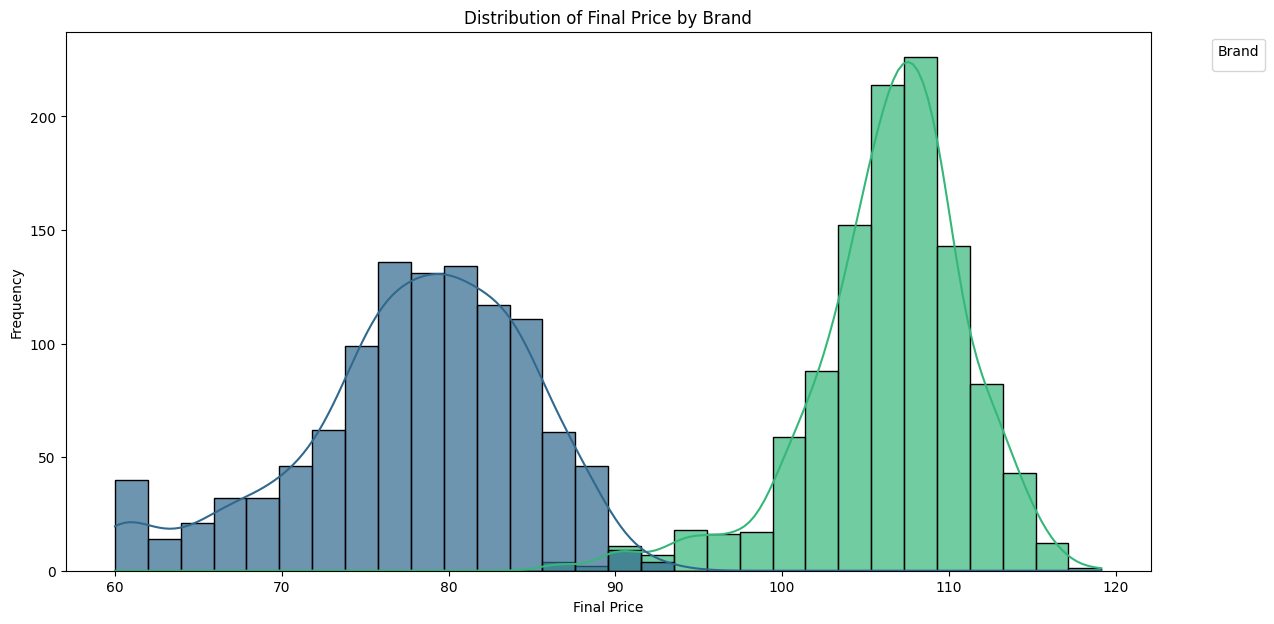

In [19]:
plt.figure(figsize=(14, 7))

# Plot the distribution of final price for both brands
sns.histplot(data=competitor_df, x='FinalPrice', hue='Brand', kde=True, bins=30, palette='viridis', alpha=0.7)
plt.title('Distribution of Final Price by Brand')
plt.xlabel('Final Price')
plt.ylabel('Frequency')
plt.legend(title='Brand', bbox_to_anchor=(1.05, 1), loc='upper left')
# plt.legend(title='Brand')
plt.show()